📁 LOADING ALL DATASETS

1️⃣ LOADING OMNIGLOT (Greek and other alphabets)

📂 Omniglot - images_background (Training alphabets):

📥 Loading Omniglot from: C:\Users\mp672\OneDrive\Desktop\Few_shot_learning\Git_file\few-shot-ivc-master\few-shot-ivc-master\datasets\Omniglot_Raw\images_background
   Found 30 alphabets
   Loaded 100 characters so far...
   Loaded 200 characters so far...
   Loaded 300 characters so far...
   Loaded 400 characters so far...
   Loaded 500 characters so far...
   Loaded 600 characters so far...
   Loaded 700 characters so far...
   Loaded 800 characters so far...
   Loaded 900 characters so far...
   ✅ Loaded 9640 images from 964 character classes

   🇬🇷 Greek character classes found: 24
      Examples: ['Greek_character01', 'Greek_character02', 'Greek_character03', 'Greek_character04', 'Greek_character05']

   📊 Statistics:
   Total classes: 964
   Total images: 9640
   Min images/class: 10
   Max images/class: 10
   Avg images/class: 10.0


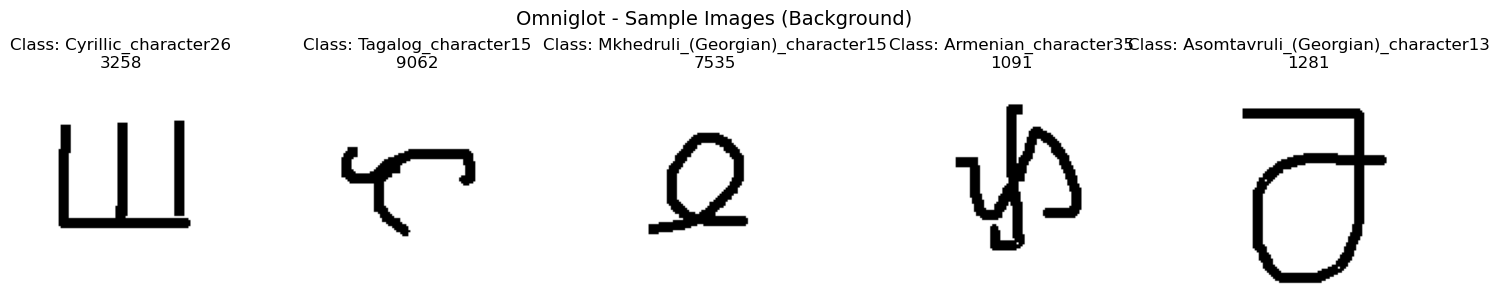


📂 Omniglot - images_evaluation (Testing alphabets):

📥 Loading Omniglot from: C:\Users\mp672\OneDrive\Desktop\Few_shot_learning\Git_file\few-shot-ivc-master\few-shot-ivc-master\datasets\Omniglot_Raw\images_evaluation
   Found 20 alphabets
   Loaded 100 characters so far...
   Loaded 200 characters so far...
   Loaded 300 characters so far...
   Loaded 400 characters so far...
   Loaded 500 characters so far...
   Loaded 600 characters so far...
   ✅ Loaded 6590 images from 659 character classes

   📊 Statistics:
   Total classes: 659
   Total images: 6590
   Min images/class: 10
   Max images/class: 10
   Avg images/class: 10.0

2️⃣ LOADING MAHADEVANDATA (Indus Valley Script)

📂 MahadevanData - images_background (Training split):

📥 Loading MahadevanData from: C:\Users\mp672\OneDrive\Desktop\Few_shot_learning\Git_file\few-shot-ivc-master\few-shot-ivc-master\datasets\MahadevanData_Raw\images_background
   Found 141 character classes
   Loaded 50/141 classes...
   Loaded 100/141 classes

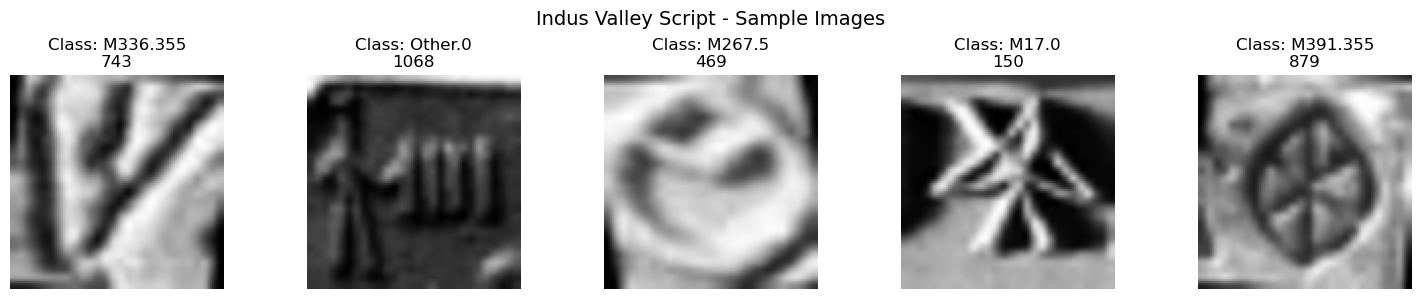


📊 DATASET LOADING SUMMARY

┌─────────────────────────────────────────────────────────────────┐
│                      DATASETS LOADED SUCCESSFULLY              │
├─────────────────────────────────────────────────────────────────┤
│ Omniglot (Background):                                         │
│   - Classes: 964                                          │
│   - Images: 9640                                             │
│   - Includes Greek: Yes                                        │
├─────────────────────────────────────────────────────────────────┤
│ Omniglot (Evaluation):                                         │
│   - Classes: 659                                          │
│   - Images: 6590                                             │
├─────────────────────────────────────────────────────────────────┤
│ MahadevanData (Background):                                    │
│   - Classes: 141                                          │
│   - Images: 4014                               

In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

datasets_path = Path(r"C:\Users\mp672\OneDrive\Desktop\Few_shot_learning\Git_file\few-shot-ivc-master\few-shot-ivc-master\datasets")

# ============================================
# FUNCTION 1: Load Omniglot (Nested Structure)
# Structure: alphabet_folder/character_folder/images
# ============================================
def load_omniglot(dataset_path, max_images_per_class=None):
    """
    Load Omniglot dataset with nested folder structure
    Args:
        dataset_path: Path to images_background or images_evaluation
        max_images_per_class: Limit images per class (None = load all)
    Returns:
        images: numpy array of images
        labels: numpy array of labels
        class_names: list of class names (alphabet_character)
    """
    images = []
    labels = []
    class_names = []
    class_idx = 0
    
    print(f"\n📥 Loading Omniglot from: {dataset_path}")
    
    # Get all alphabet folders
    alphabet_folders = [f for f in dataset_path.iterdir() if f.is_dir()]
    print(f"   Found {len(alphabet_folders)} alphabets")
    
    for alphabet in alphabet_folders:
        # Get all character folders inside each alphabet
        char_folders = [f for f in alphabet.iterdir() if f.is_dir()]
        
        for char_folder in char_folders:
            class_name = f"{alphabet.name}_{char_folder.name}"
            class_names.append(class_name)
            
            # Get all images
            image_files = list(char_folder.glob("*.png")) + list(char_folder.glob("*.PNG"))
            
            if max_images_per_class:
                image_files = image_files[:max_images_per_class]
            
            for img_path in image_files:
                try:
                    img = Image.open(img_path).convert('L')
                    img = img.resize((105, 105))
                    img_array = np.array(img, dtype=np.float32) / 255.0
                    images.append(img_array)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"      ⚠️ Error loading {img_path.name}: {e}")
            
            class_idx += 1
            
            if class_idx % 100 == 0:
                print(f"   Loaded {class_idx} characters so far...")
    
    print(f"   ✅ Loaded {len(images)} images from {len(class_names)} character classes")
    return np.array(images), np.array(labels), class_names


# ============================================
# FUNCTION 2: Load MahadevanData (Flat Structure)
# Structure: character_folder/images
# ============================================
def load_mahadevan(dataset_path, max_images_per_class=None):
    """
    Load MahadevanData (Indus Valley) dataset with flat structure
    Args:
        dataset_path: Path to images_background or images_evaluation
        max_images_per_class: Limit images per class (None = load all)
    Returns:
        images: numpy array of images
        labels: numpy array of labels
        class_names: list of class names
    """
    images = []
    labels = []
    class_names = []
    class_idx = 0
    
    print(f"\n📥 Loading MahadevanData from: {dataset_path}")
    
    # Get all character folders
    char_folders = [f for f in dataset_path.iterdir() if f.is_dir()]
    print(f"   Found {len(char_folders)} character classes")
    
    for char_folder in char_folders:
        class_name = char_folder.name
        class_names.append(class_name)
        
        # Get all images
        image_files = list(char_folder.glob("*.png")) + list(char_folder.glob("*.PNG")) + \
                     list(char_folder.glob("*.jpg")) + list(char_folder.glob("*.JPG"))
        
        if max_images_per_class:
            image_files = image_files[:max_images_per_class]
        
        for img_path in image_files:
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((105, 105))
                img_array = np.array(img, dtype=np.float32) / 255.0
                images.append(img_array)
                labels.append(class_idx)
            except Exception as e:
                print(f"      ⚠️ Error loading {img_path.name}: {e}")
        
        class_idx += 1
        
        if class_idx % 50 == 0:
            print(f"   Loaded {class_idx}/{len(char_folders)} classes...")
    
    print(f"   ✅ Loaded {len(images)} images from {len(class_names)} character classes")
    return np.array(images), np.array(labels), class_names


# ============================================
# FUNCTION 3: Visualize Samples
# ============================================
def visualize_samples(images, labels, class_names, title="Sample Images", num_samples=5):
    """Display sample images from the dataset"""
    
    if len(images) == 0:
        print("No images to display")
        return
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle(title, fontsize=14)
    
    # Get random indices
    indices = random.sample(range(len(images)), min(num_samples, len(images)))
    
    for i, idx in enumerate(indices):
        axes[i].imshow(images[idx], cmap='gray')
        axes[i].set_title(f"Class: {class_names[labels[idx]]}\n{idx}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


# ============================================
# FUNCTION 4: Get Class Statistics
# ============================================
def get_statistics(images, labels, class_names):
    """Print statistics about the dataset"""
    
    unique_labels = np.unique(labels)
    images_per_class = [np.sum(labels == label) for label in unique_labels]
    
    print(f"   Total classes: {len(unique_labels)}")
    print(f"   Total images: {len(images)}")
    print(f"   Min images/class: {min(images_per_class)}")
    print(f"   Max images/class: {max(images_per_class)}")
    print(f"   Avg images/class: {np.mean(images_per_class):.1f}")
    
    return images_per_class


# ============================================
# MAIN: LOAD ALL DATASETS
# ============================================
print("=" * 70)
print("📁 LOADING ALL DATASETS")
print("=" * 70)

# Dictionary to store all loaded datasets
datasets_loaded = {}

# ============================================
# 1. LOAD OMNIGLOT (for pre-training with Greek)
# ============================================
print("\n" + "=" * 70)
print("1️⃣ LOADING OMNIGLOT (Greek and other alphabets)")
print("=" * 70)

omniglot_bg_path = datasets_path / "Omniglot_Raw" / "images_background"
omniglot_eval_path = datasets_path / "Omniglot_Raw" / "images_evaluation"

if omniglot_bg_path.exists():
    print("\n📂 Omniglot - images_background (Training alphabets):")
    omniglot_bg_images, omniglot_bg_labels, omniglot_bg_classes = load_omniglot(
        omniglot_bg_path,
        max_images_per_class=10  # Change to None to load all images
    )
    datasets_loaded['omniglot_background'] = {
        'images': omniglot_bg_images,
        'labels': omniglot_bg_labels,
        'classes': omniglot_bg_classes
    }
    
    # Check if Greek is present
    greek_classes = [c for c in omniglot_bg_classes if 'Greek' in c]
    print(f"\n   🇬🇷 Greek character classes found: {len(greek_classes)}")
    if greek_classes:
        print(f"      Examples: {greek_classes[:5]}")
    
    # Statistics
    print(f"\n   📊 Statistics:")
    get_statistics(omniglot_bg_images, omniglot_bg_labels, omniglot_bg_classes)
    
    # Visualize samples
    if len(omniglot_bg_images) > 0:
        visualize_samples(omniglot_bg_images, omniglot_bg_labels, omniglot_bg_classes, 
                         title="Omniglot - Sample Images (Background)", num_samples=5)

if omniglot_eval_path.exists():
    print("\n📂 Omniglot - images_evaluation (Testing alphabets):")
    omniglot_eval_images, omniglot_eval_labels, omniglot_eval_classes = load_omniglot(
        omniglot_eval_path,
        max_images_per_class=10
    )
    datasets_loaded['omniglot_evaluation'] = {
        'images': omniglot_eval_images,
        'labels': omniglot_eval_labels,
        'classes': omniglot_eval_classes
    }
    
    print(f"\n   📊 Statistics:")
    get_statistics(omniglot_eval_images, omniglot_eval_labels, omniglot_eval_classes)

# ============================================
# 2. LOAD MAHADEVANDATA (Indus Valley Script)
# ============================================
print("\n" + "=" * 70)
print("2️⃣ LOADING MAHADEVANDATA (Indus Valley Script)")
print("=" * 70)

mahadevan_bg_path = datasets_path / "MahadevanData_Raw" / "images_background"
mahadevan_eval_path = datasets_path / "MahadevanData_Raw" / "images_evaluation"

if mahadevan_bg_path.exists():
    print("\n📂 MahadevanData - images_background (Training split):")
    mahadevan_bg_images, mahadevan_bg_labels, mahadevan_bg_classes = load_mahadevan(
        mahadevan_bg_path,
        max_images_per_class=None  # Load all images
    )
    datasets_loaded['mahadevan_background'] = {
        'images': mahadevan_bg_images,
        'labels': mahadevan_bg_labels,
        'classes': mahadevan_bg_classes
    }
    
    print(f"\n   📊 Statistics:")
    get_statistics(mahadevan_bg_images, mahadevan_bg_labels, mahadevan_bg_classes)

if mahadevan_eval_path.exists():
    print("\n📂 MahadevanData - images_evaluation (Testing split):")
    mahadevan_eval_images, mahadevan_eval_labels, mahadevan_eval_classes = load_mahadevan(
        mahadevan_eval_path,
        max_images_per_class=None
    )
    datasets_loaded['mahadevan_evaluation'] = {
        'images': mahadevan_eval_images,
        'labels': mahadevan_eval_labels,
        'classes': mahadevan_eval_classes
    }
    
    print(f"\n   📊 Statistics:")
    get_statistics(mahadevan_eval_images, mahadevan_eval_labels, mahadevan_eval_classes)
    
    # Visualize Indus Valley samples
    if len(mahadevan_eval_images) > 0:
        visualize_samples(mahadevan_eval_images, mahadevan_eval_labels, mahadevan_eval_classes,
                         title="Indus Valley Script - Sample Images", num_samples=5)

# ============================================
# SUMMARY
# ============================================
print("\n" + "=" * 70)
print("📊 DATASET LOADING SUMMARY")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                      DATASETS LOADED SUCCESSFULLY              │
├─────────────────────────────────────────────────────────────────┤
│ Omniglot (Background):                                         │
│   - Classes: {len(datasets_loaded.get('omniglot_background', {}).get('classes', []))}                                          │
│   - Images: {len(datasets_loaded.get('omniglot_background', {}).get('images', []))}                                             │
│   - Includes Greek: Yes                                        │
├─────────────────────────────────────────────────────────────────┤
│ Omniglot (Evaluation):                                         │
│   - Classes: {len(datasets_loaded.get('omniglot_evaluation', {}).get('classes', []))}                                          │
│   - Images: {len(datasets_loaded.get('omniglot_evaluation', {}).get('images', []))}                                             │
├─────────────────────────────────────────────────────────────────┤
│ MahadevanData (Background):                                    │
│   - Classes: {len(datasets_loaded.get('mahadevan_background', {}).get('classes', []))}                                          │
│   - Images: {len(datasets_loaded.get('mahadevan_background', {}).get('images', []))}                                             │
├─────────────────────────────────────────────────────────────────┤
│ MahadevanData (Evaluation):                                    │
│   - Classes: {len(datasets_loaded.get('mahadevan_evaluation', {}).get('classes', []))}                                          │
│   - Images: {len(datasets_loaded.get('mahadevan_evaluation', {}).get('images', []))}                                             │
└─────────────────────────────────────────────────────────────────┘
""")

print("\n✅ All datasets loaded successfully!")
print("\n📌 Next Steps:")
print("   - Use 'omniglot_background' for pre-training (includes Greek)")
print("   - Use 'mahadevan_background' for few-shot meta-training")
print("   - Use 'mahadevan_evaluation' for few-shot testing")

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=" * 70)
print("CODE 2: CNN ENCODER (Feature Extractor)")
print("=" * 70)

# ============================================
# CNN ENCODER - Learns patterns from images
# ============================================

class CNNEncoder(nn.Module):
    """
    Convolutional Neural Network that extracts features from images.
    This is the "pattern learner" - it learns what strokes, curves, 
    and shapes look like from Greek and other scripts.
    
    Input:  105x105 grayscale image
    Output: 64-dimensional feature vector (the "fingerprint" of the image)
    """
    
    def __init__(self):
        super(CNNEncoder, self).__init__()
        
        # Layer 1: Detect basic edges and curves
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        # Layer 2: Detect more complex patterns (corners, loops)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Layer 3: Detect higher-level shapes (characters parts)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # Layer 4: Final feature extraction
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        # Max pooling reduces image size (105 → 52 → 26 → 13 → 6)
        self.pool = nn.MaxPool2d(2)
        
        # Activation function
        self.relu = nn.ReLU()
        
    def forward(self, x):
        """
        Forward pass through the network
        
        Args:
            x: Input images (batch_size, 1, 105, 105)
            
        Returns:
            features: Feature vectors (batch_size, 64)
        """
        
        # Block 1: 105x105 → 52x52
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        
        # Block 2: 52x52 → 26x26
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        
        # Block 3: 26x26 → 13x13
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        
        # Block 4: 13x13 → 6x6
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        
        # Global average pooling: 6x6x64 → 64
        # Takes the average of each 6x6 feature map
        x = torch.mean(x, dim=(2, 3))
        
        return x


# ============================================
# TEST THE ENCODER
# ============================================

print("\n🔧 Creating CNN Encoder...")
encoder = CNNEncoder()
print(f"✅ CNN Encoder created successfully!")

# Count total parameters
total_params = sum(p.numel() for p in encoder.parameters())
trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Input shape: (batch, 1, 105, 105)")
print(f"   Output shape: (batch, 64)")

# Test with a dummy input
print(f"\n🧪 Testing with dummy input...")
test_input = torch.randn(1, 1, 105, 105)
test_output = encoder(test_input)
print(f"   Input shape: {test_input.shape}")
print(f"   Output shape: {test_output.shape}")
print(f"   ✅ Encoder working correctly!")

print("\n" + "=" * 70)
print("✅ CODE 2 COMPLETE: CNN Encoder is ready!")
print("   Next: Code 3 - Prototypical Network")
print("=" * 70)

CODE 2: CNN ENCODER (Feature Extractor)

🔧 Creating CNN Encoder...
✅ CNN Encoder created successfully!

📊 Model Statistics:
   Total parameters: 111,936
   Trainable parameters: 111,936
   Input shape: (batch, 1, 105, 105)
   Output shape: (batch, 64)

🧪 Testing with dummy input...
   Input shape: torch.Size([1, 1, 105, 105])
   Output shape: torch.Size([1, 64])
   ✅ Encoder working correctly!

✅ CODE 2 COMPLETE: CNN Encoder is ready!
   Next: Code 3 - Prototypical Network


Prototypical Network

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=" * 70)
print("CODE 3: PROTOTYPICAL NETWORK (Few-Shot Learning Core)")
print("=" * 70)

# ============================================
# PROTOTYPICAL NETWORK
# ============================================

class PrototypicalNetwork(nn.Module):
    """
    Prototypical Network for Few-Shot Learning.
    
    How it works:
    1. Takes support images (few examples of each class)
    2. Creates a "prototype" (average) for each class
    3. Takes query images (new images to classify)
    4. Compares query images to prototypes
    5. Classifies based on closest prototype
    
    This is the core of your project!
    """
    
    def __init__(self, encoder):
        """
        Args:
            encoder: CNNEncoder that extracts features from images
        """
        super(PrototypicalNetwork, self).__init__()
        self.encoder = encoder
        
    def forward(self, support_images, support_labels, query_images):
        """
        Forward pass through prototypical network
        
        Args:
            support_images: (n_way * n_support, 1, 105, 105)
                           Examples to learn from
            support_labels: (n_way * n_support,)
                           Labels for support images
            query_images: (n_way * n_query, 1, 105, 105)
                         Images to classify
                         
        Returns:
            logits: (n_way * n_query, n_way)
                   Classification scores for query images
        """
        
        # Step 1: Encode ALL images (support + query)
        # This extracts features using the CNN learned from Greek
        support_features = self.encoder(support_images)
        query_features = self.encoder(query_images)
        
        # Step 2: Create prototypes (average of support features per class)
        # For each unique class, compute the mean of its support examples
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for label in unique_labels:
            # Get all support features for this class
            class_features = support_features[support_labels == label]
            # Compute prototype = average of features
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        # Stack all prototypes: (n_way, feature_dim)
        prototypes = torch.stack(prototypes)
        
        # Step 3: Compute distances between query features and prototypes
        # Euclidean distance: sqrt((q - p)^2)
        distances = torch.cdist(query_features, prototypes)
        # distances shape: (n_query, n_way)
        
        # Step 4: Convert distances to logits (negative distance = closer = higher score)
        logits = -distances
        
        return logits
    
    def get_prototypes(self, support_images, support_labels):
        """
        Get prototypes without classification (useful for visualization)
        
        Args:
            support_images: (n_way * n_support, 1, 105, 105)
            support_labels: (n_way * n_support,)
            
        Returns:
            prototypes: (n_way, 64) - feature vectors for each class
            unique_labels: (n_way,) - corresponding labels
        """
        support_features = self.encoder(support_images)
        
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for label in unique_labels:
            class_features = support_features[support_labels == label]
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        return torch.stack(prototypes), unique_labels


# ============================================
# TEST THE PROTOTYPICAL NETWORK
# ============================================

print("\n🔧 Creating CNN Encoder first...")

# First create the encoder (from Code #2)
class CNNEncoder(nn.Module):
    def __init__(self):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = torch.mean(x, dim=(2, 3))
        return x

# Create encoder and prototypical network
encoder = CNNEncoder()
model = PrototypicalNetwork(encoder)

print(f"✅ CNN Encoder created")
print(f"✅ Prototypical Network created")
print(f"\n📊 Model Structure:")
print(f"   Encoder: 4 Conv layers → 64 features")
print(f"   Prototypical Network: Creates prototypes from support examples")

# Test with dummy data
print(f"\n🧪 Testing with dummy data...")

# Simulate a 5-way, 5-shot episode
n_way = 5        # 5 different classes
n_support = 5    # 5 examples per class
n_query = 15     # 15 examples per class to test

# Create dummy images
support_images = torch.randn(n_way * n_support, 1, 105, 105)
support_labels = torch.tensor([i for i in range(n_way) for _ in range(n_support)])
query_images = torch.randn(n_way * n_query, 1, 105, 105)
query_labels = torch.tensor([i for i in range(n_way) for _ in range(n_query)])

print(f"\n📊 Episode Configuration:")
print(f"   n_way (number of classes): {n_way}")
print(f"   n_support (examples per class): {n_support}")
print(f"   n_query (test examples per class): {n_query}")
print(f"   Support set size: {support_images.shape[0]} images")
print(f"   Query set size: {query_images.shape[0]} images")

# Forward pass
logits = model(support_images, support_labels, query_images)
print(f"\n📊 Output:")
print(f"   Logits shape: {logits.shape}")
print(f"   (Should be {n_way * n_query} queries × {n_way} classes)")

# Get predictions
predictions = torch.argmax(logits, dim=1)
print(f"   Predictions shape: {predictions.shape}")

# Calculate accuracy
accuracy = (predictions == query_labels).float().mean().item()
print(f"\n🎯 Test Accuracy on Dummy Data: {accuracy:.2%}")
print(f"   (This is just a test - real accuracy will come from actual training!)")

# Show how prototypes work
print(f"\n🔬 How Prototypes Work (Example):")
print(f"   For each class, we take {n_support} support examples:")
print(f"   Class 0: [feat1] [feat2] [feat3] [feat4] [feat5]")
print(f"            ↓")
print(f"   Prototype: [average of all 5]")
print(f"            ↓")
print(f"   Compare query images to prototypes → classify")

print("\n" + "=" * 70)
print("✅ CODE 3 COMPLETE: Prototypical Network is ready!")
print("   Next: Code 4 - Episode Generator (creates few-shot episodes)")
print("=" * 70)

CODE 3: PROTOTYPICAL NETWORK (Few-Shot Learning Core)

🔧 Creating CNN Encoder first...
✅ CNN Encoder created
✅ Prototypical Network created

📊 Model Structure:
   Encoder: 4 Conv layers → 64 features
   Prototypical Network: Creates prototypes from support examples

🧪 Testing with dummy data...

📊 Episode Configuration:
   n_way (number of classes): 5
   n_support (examples per class): 5
   n_query (test examples per class): 15
   Support set size: 25 images
   Query set size: 75 images

📊 Output:
   Logits shape: torch.Size([75, 5])
   (Should be 75 queries × 5 classes)
   Predictions shape: torch.Size([75])

🎯 Test Accuracy on Dummy Data: 22.67%
   (This is just a test - real accuracy will come from actual training!)

🔬 How Prototypes Work (Example):
   For each class, we take 5 support examples:
   Class 0: [feat1] [feat2] [feat3] [feat4] [feat5]
            ↓
   Prototype: [average of all 5]
            ↓
   Compare query images to prototypes → classify

✅ CODE 3 COMPLETE: Prototyp

Episode Generator

In [6]:
import torch
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader

print("=" * 70)
print("CODE 4: EPISODE GENERATOR (Creates Few-Shot Episodes)")
print("=" * 70)

# ============================================
# DATASET CLASS FOR FEW-SHOT LEARNING
# ============================================

class FewShotDataset(Dataset):
    """
    Wrapper for numpy arrays to work with PyTorch
    Converts your loaded images into a PyTorch dataset
    """
    
    def __init__(self, images, labels, class_names):
        """
        Args:
            images: numpy array of shape (n_images, 105, 105)
            labels: numpy array of shape (n_images,)
            class_names: list of class names
        """
        # Add channel dimension and convert to tensor
        self.images = torch.FloatTensor(images).unsqueeze(1)  # (n, 1, 105, 105)
        self.labels = torch.LongTensor(labels)
        self.class_names = class_names
        self.classes = torch.unique(self.labels).tolist()
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


# ============================================
# EPISODE GENERATOR
# ============================================

class EpisodeGenerator:
    """
    Creates episodes for few-shot learning.
    
    An episode is a small training task that contains:
    - Support set: Few examples to learn from
    - Query set: Examples to classify
    
    This mimics how the model will be tested on new scripts!
    """
    
    def __init__(self, dataset, n_way, n_support, n_query):
        """
        Args:
            dataset: FewShotDataset containing all images and labels
            n_way: Number of classes per episode (e.g., 5)
            n_support: Number of support examples per class (e.g., 1 or 5)
            n_query: Number of query examples per class (e.g., 15)
        """
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        
        # Get all unique classes
        self.classes = dataset.classes
        
    def create_episode(self):
        """
        Create one episode (support set + query set)
        
        Returns:
            support_images: (n_way * n_support, 1, 105, 105)
            support_labels: (n_way * n_support,)
            query_images: (n_way * n_query, 1, 105, 105)
            query_labels: (n_way * n_query,)
        """
        
        # Step 1: Select n_way random classes for this episode
        episode_classes = random.sample(self.classes, self.n_way)
        
        support_images = []
        support_labels = []
        query_images = []
        query_labels = []
        
        # Step 2: For each selected class, pick support and query examples
        for label_idx, class_label in enumerate(episode_classes):
            # Get all indices for this class
            class_indices = torch.where(self.dataset.labels == class_label)[0].tolist()
            
            # Make sure we have enough examples
            if len(class_indices) < self.n_support + self.n_query:
                # If not enough, sample with replacement
                class_indices = class_indices * (self.n_support + self.n_query)
            
            # Randomly select support and query examples
            selected = random.sample(class_indices, self.n_support + self.n_query)
            support_idx = selected[:self.n_support]
            query_idx = selected[self.n_support:]
            
            # Add to episode
            for idx in support_idx:
                support_images.append(self.dataset.images[idx])
                support_labels.append(label_idx)
            
            for idx in query_idx:
                query_images.append(self.dataset.images[idx])
                query_labels.append(label_idx)
        
        # Step 3: Stack into tensors
        support_images = torch.stack(support_images)
        support_labels = torch.tensor(support_labels)
        query_images = torch.stack(query_images)
        query_labels = torch.tensor(query_labels)
        
        return support_images, support_labels, query_images, query_labels
    
    def create_episode_batch(self, n_episodes):
        """
        Create multiple episodes at once
        
        Args:
            n_episodes: Number of episodes to create
            
        Returns:
            List of episodes, each containing (support_images, support_labels, 
                                            query_images, query_labels)
        """
        episodes = []
        for _ in range(n_episodes):
            episode = self.create_episode()
            episodes.append(episode)
        return episodes


# ============================================
# TEST WITH DUMMY DATA
# ============================================

print("\n🔧 Creating dummy dataset for testing...")

# Create dummy data (1000 images, 50 classes)
dummy_images = np.random.rand(1000, 105, 105).astype(np.float32)
dummy_labels = np.random.randint(0, 50, size=1000)
dummy_class_names = [f"Class_{i}" for i in range(50)]

dummy_dataset = FewShotDataset(dummy_images, dummy_labels, dummy_class_names)
print(f"✅ Dummy dataset created: {len(dummy_dataset)} images, {len(dummy_dataset.classes)} classes")

# ============================================
# TEST 5-WAY, 5-SHOT EPISODES
# ============================================

print("\n" + "=" * 70)
print("TEST 1: 5-Way, 5-Shot Episodes")
print("=" * 70)

# Create episode generator
episode_gen_5shot = EpisodeGenerator(
    dataset=dummy_dataset,
    n_way=5,        # 5 classes per episode
    n_support=5,    # 5 support examples per class
    n_query=15      # 15 query examples per class
)

print(f"\n📊 Episode Generator Configuration:")
print(f"   n_way: {episode_gen_5shot.n_way}")
print(f"   n_support: {episode_gen_5shot.n_support}")
print(f"   n_query: {episode_gen_5shot.n_query}")
print(f"   Total classes available: {len(episode_gen_5shot.classes)}")

# Create one episode
support_imgs, support_lbls, query_imgs, query_lbls = episode_gen_5shot.create_episode()

print(f"\n📊 Episode Created:")
print(f"   Support images: {support_imgs.shape}")
print(f"   Support labels: {support_lbls.shape}")
print(f"   Query images: {query_imgs.shape}")
print(f"   Query labels: {query_lbls.shape}")

# Verify shapes
expected_support = episode_gen_5shot.n_way * episode_gen_5shot.n_support
expected_query = episode_gen_5shot.n_way * episode_gen_5shot.n_query

print(f"\n✅ Shape Verification:")
print(f"   Support should be {expected_support} images: {support_imgs.shape[0] == expected_support}")
print(f"   Query should be {expected_query} images: {query_imgs.shape[0] == expected_query}")

# ============================================
# TEST 5-WAY, 1-SHOT EPISODES
# ============================================

print("\n" + "=" * 70)
print("TEST 2: 5-Way, 1-Shot Episodes")
print("=" * 70)

# Create 1-shot episode generator
episode_gen_1shot = EpisodeGenerator(
    dataset=dummy_dataset,
    n_way=5,        # 5 classes per episode
    n_support=1,    # 1 support example per class (1-shot)
    n_query=15      # 15 query examples per class
)

print(f"\n📊 Episode Generator Configuration:")
print(f"   n_way: {episode_gen_1shot.n_way}")
print(f"   n_support: {episode_gen_1shot.n_support} (1-shot!)")
print(f"   n_query: {episode_gen_1shot.n_query}")

# Create one episode
support_imgs, support_lbls, query_imgs, query_lbls = episode_gen_1shot.create_episode()

print(f"\n📊 Episode Created:")
print(f"   Support images: {support_imgs.shape}")
print(f"   Support labels: {support_lbls.shape}")
print(f"   Query images: {query_imgs.shape}")
print(f"   Query labels: {query_lbls.shape}")

# ============================================
# TEST BATCH OF EPISODES
# ============================================

print("\n" + "=" * 70)
print("TEST 3: Batch of Episodes")
print("=" * 70)

n_episodes = 5
episodes = episode_gen_5shot.create_episode_batch(n_episodes)

print(f"\n📊 Created {n_episodes} episodes:")
for i, (sup_imgs, sup_lbls, q_imgs, q_lbls) in enumerate(episodes):
    print(f"   Episode {i+1}: Support {sup_imgs.shape}, Query {q_imgs.shape}")

# ============================================
# VISUALIZE EPISODE STRUCTURE
# ============================================

print("\n" + "=" * 70)
print("HOW AN EPISODE WORKS")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────┐
│                     EPISODE STRUCTURE                           │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  SUPPORT SET (Learn from these)                                │
│  ┌─────────────────────────────────────────────────────────┐   │
│  │ Class A: [img1] [img2] [img3] [img4] [img5]            │   │
│  │ Class B: [img1] [img2] [img3] [img4] [img5]            │   │
│  │ Class C: [img1] [img2] [img3] [img4] [img5]            │   │
│  │ Class D: [img1] [img2] [img3] [img4] [img5]            │   │
│  │ Class E: [img1] [img2] [img3] [img4] [img5]            │   │
│  └─────────────────────────────────────────────────────────┘   │
│                           ↓                                    │
│              Model creates PROTOTYPES                          │
│                           ↓                                    │
│  QUERY SET (Test these)                                        │
│  ┌─────────────────────────────────────────────────────────┐   │
│  │ Class A: [q1] [q2] [q3] ... [q15]  → Should predict A  │   │
│  │ Class B: [q1] [q2] [q3] ... [q15]  → Should predict B  │   │
│  │ Class C: [q1] [q2] [q3] ... [q15]  → Should predict C  │   │
│  │ Class D: [q1] [q2] [q3] ... [q15]  → Should predict D  │   │
│  │ Class E: [q1] [q2] [q3] ... [q15]  → Should predict E  │   │
│  └─────────────────────────────────────────────────────────┘   │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘

This is how the model learns to classify new symbols from few examples!
""")

print("\n" + "=" * 70)
print("✅ CODE 4 COMPLETE: Episode Generator is ready!")
print("   Next: Code 5 - Training Loop (puts everything together)")
print("=" * 70)

CODE 4: EPISODE GENERATOR (Creates Few-Shot Episodes)

🔧 Creating dummy dataset for testing...
✅ Dummy dataset created: 1000 images, 50 classes

TEST 1: 5-Way, 5-Shot Episodes

📊 Episode Generator Configuration:
   n_way: 5
   n_support: 5
   n_query: 15
   Total classes available: 50

📊 Episode Created:
   Support images: torch.Size([25, 1, 105, 105])
   Support labels: torch.Size([25])
   Query images: torch.Size([75, 1, 105, 105])
   Query labels: torch.Size([75])

✅ Shape Verification:
   Support should be 25 images: True
   Query should be 75 images: True

TEST 2: 5-Way, 1-Shot Episodes

📊 Episode Generator Configuration:
   n_way: 5
   n_support: 1 (1-shot!)
   n_query: 15

📊 Episode Created:
   Support images: torch.Size([5, 1, 105, 105])
   Support labels: torch.Size([5])
   Query images: torch.Size([75, 1, 105, 105])
   Query labels: torch.Size([75])

TEST 3: Batch of Episodes

📊 Created 5 episodes:
   Episode 1: Support torch.Size([25, 1, 105, 105]), Query torch.Size([75, 1, 

Complete Training Loop

CODE 5: COMPLETE TRAINING LOOP
Few-Shot Learning on Indus Valley Script

STEP 1: Loading Your Actual Datasets

📂 Loading MahadevanData (Indus Valley Script)...

📂 Background split (for meta-training):
   Found 141 character classes
   ✅ Loaded 4014 images from 141 classes

📂 Evaluation split (for meta-testing):
   Found 141 character classes
   ✅ Loaded 1104 images from 141 classes

STEP 2: Creating PyTorch Datasets

✅ Training dataset: 4014 images, 141 classes
✅ Test dataset: 1104 images, 141 classes

STEP 3: Building CNN Encoder

STEP 4: Building Prototypical Network

✅ Model created with 111,936 parameters

STEP 5: Creating Episode Generator

STEP 6: Starting Training

📊 Training Configuration:
   n_way: 5 (classes per episode)
   n_support: 5 (examples to learn from)
   n_query: 15 (examples to test)
   n_episodes: 500
   Learning rate: 0.001

🚀 Training started...
   Episode 100/500 | Loss: 0.7214 | Acc: 0.7665
   Episode 200/500 | Loss: 0.5403 | Acc: 0.8253
   Episode 300/500 | L

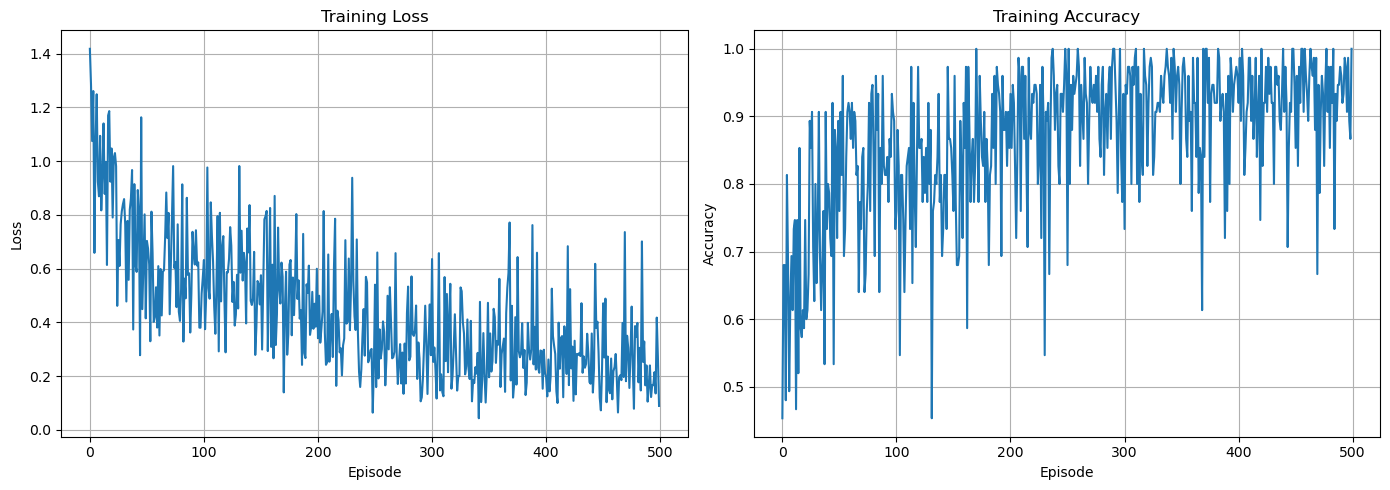


🎯 FINAL RESULTS

┌─────────────────────────────────────────────────────────────────┐
│                    FEW-SHOT LEARNING RESULTS                    │
│                         Indus Valley Script                     │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   Training:                                                     │
│   ├── Episodes: 500                                            │
│   ├── Final Training Loss: 0.0894                                   │
│   └── Final Training Accuracy: 1.0000                                   │
│                                                                 │
│   Testing (5-way classification):                               │
│   ├── 1-shot: 89.68% ± 8.66%                      │
│   └── 5-shot: 95.28% ± 5.12%                      │
│                                                                 │
└──────────────────────────────────────────────

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

print("=" * 70)
print("CODE 5: COMPLETE TRAINING LOOP")
print("Few-Shot Learning on Indus Valley Script")
print("=" * 70)

# ============================================
# STEP 1: LOAD YOUR ACTUAL DATA
# ============================================

print("\n" + "=" * 70)
print("STEP 1: Loading Your Actual Datasets")
print("=" * 70)

# Set path to your datasets
datasets_path = Path(r"C:\Users\mp672\OneDrive\Desktop\Few_shot_learning\Git_file\few-shot-ivc-master\few-shot-ivc-master\datasets")

# Function to load MahadevanData (from Code 1)
def load_mahadevan(dataset_path):
    images = []
    labels = []
    class_names = []
    class_idx = 0
    
    char_folders = [f for f in dataset_path.iterdir() if f.is_dir()]
    print(f"   Found {len(char_folders)} character classes")
    
    for char_folder in char_folders:
        class_names.append(char_folder.name)
        image_files = list(char_folder.glob("*.png")) + list(char_folder.glob("*.PNG")) + \
                     list(char_folder.glob("*.jpg")) + list(char_folder.glob("*.JPG"))
        
        for img_path in image_files:
            try:
                from PIL import Image
                img = Image.open(img_path).convert('L')
                img = img.resize((105, 105))
                img_array = np.array(img, dtype=np.float32) / 255.0
                images.append(img_array)
                labels.append(class_idx)
            except:
                pass
        class_idx += 1
    
    return np.array(images), np.array(labels), class_names

# Load MahadevanData (Indus Valley)
print("\n📂 Loading MahadevanData (Indus Valley Script)...")
mahadevan_bg_path = datasets_path / "MahadevanData_Raw" / "images_background"
mahadevan_eval_path = datasets_path / "MahadevanData_Raw" / "images_evaluation"

if mahadevan_bg_path.exists():
    print("\n📂 Background split (for meta-training):")
    train_images, train_labels, train_classes = load_mahadevan(mahadevan_bg_path)
    print(f"   ✅ Loaded {len(train_images)} images from {len(train_classes)} classes")

if mahadevan_eval_path.exists():
    print("\n📂 Evaluation split (for meta-testing):")
    test_images, test_labels, test_classes = load_mahadevan(mahadevan_eval_path)
    print(f"   ✅ Loaded {len(test_images)} images from {len(test_classes)} classes")

# ============================================
# STEP 2: CREATE PYTORCH DATASETS
# ============================================

print("\n" + "=" * 70)
print("STEP 2: Creating PyTorch Datasets")
print("=" * 70)

class FewShotDataset:
    def __init__(self, images, labels, class_names):
        self.images = torch.FloatTensor(images).unsqueeze(1)
        self.labels = torch.LongTensor(labels)
        self.class_names = class_names
        self.classes = torch.unique(self.labels).tolist()
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset = FewShotDataset(train_images, train_labels, train_classes)
test_dataset = FewShotDataset(test_images, test_labels, test_classes)

print(f"\n✅ Training dataset: {len(train_dataset)} images, {len(train_dataset.classes)} classes")
print(f"✅ Test dataset: {len(test_dataset)} images, {len(test_dataset.classes)} classes")

# ============================================
# STEP 3: CNN ENCODER
# ============================================

print("\n" + "=" * 70)
print("STEP 3: Building CNN Encoder")
print("=" * 70)

class CNNEncoder(nn.Module):
    def __init__(self):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = torch.mean(x, dim=(2, 3))
        return x

# ============================================
# STEP 4: PROTOTYPICAL NETWORK
# ============================================

print("\n" + "=" * 70)
print("STEP 4: Building Prototypical Network")
print("=" * 70)

class PrototypicalNetwork(nn.Module):
    def __init__(self, encoder):
        super(PrototypicalNetwork, self).__init__()
        self.encoder = encoder
        
    def forward(self, support_images, support_labels, query_images):
        support_features = self.encoder(support_images)
        query_features = self.encoder(query_images)
        
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for label in unique_labels:
            class_features = support_features[support_labels == label]
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        prototypes = torch.stack(prototypes)
        distances = torch.cdist(query_features, prototypes)
        logits = -distances
        
        return logits

encoder = CNNEncoder()
model = PrototypicalNetwork(encoder)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n✅ Model created with {total_params:,} parameters")

# ============================================
# STEP 5: EPISODE GENERATOR
# ============================================

print("\n" + "=" * 70)
print("STEP 5: Creating Episode Generator")
print("=" * 70)

class EpisodeGenerator:
    def __init__(self, dataset, n_way, n_support, n_query):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.classes = dataset.classes
        
    def create_episode(self):
        episode_classes = random.sample(self.classes, self.n_way)
        
        support_images = []
        support_labels = []
        query_images = []
        query_labels = []
        
        for label_idx, class_label in enumerate(episode_classes):
            class_indices = torch.where(self.dataset.labels == class_label)[0].tolist()
            
            if len(class_indices) < self.n_support + self.n_query:
                class_indices = class_indices * (self.n_support + self.n_query)
            
            selected = random.sample(class_indices, self.n_support + self.n_query)
            support_idx = selected[:self.n_support]
            query_idx = selected[self.n_support:]
            
            for idx in support_idx:
                support_images.append(self.dataset.images[idx])
                support_labels.append(label_idx)
            
            for idx in query_idx:
                query_images.append(self.dataset.images[idx])
                query_labels.append(label_idx)
        
        support_images = torch.stack(support_images)
        support_labels = torch.tensor(support_labels)
        query_images = torch.stack(query_images)
        query_labels = torch.tensor(query_labels)
        
        return support_images, support_labels, query_images, query_labels

# ============================================
# STEP 6: TRAINING FUNCTION
# ============================================

print("\n" + "=" * 70)
print("STEP 6: Starting Training")
print("=" * 70)

def train(model, train_dataset, n_way=5, n_support=5, n_query=15, 
          n_episodes=500, learning_rate=0.001):
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    episode_gen = EpisodeGenerator(train_dataset, n_way, n_support, n_query)
    
    model.train()
    losses = []
    accuracies = []
    
    print(f"\n📊 Training Configuration:")
    print(f"   n_way: {n_way} (classes per episode)")
    print(f"   n_support: {n_support} (examples to learn from)")
    print(f"   n_query: {n_query} (examples to test)")
    print(f"   n_episodes: {n_episodes}")
    print(f"   Learning rate: {learning_rate}")
    print(f"\n🚀 Training started...")
    
    for episode in range(n_episodes):
        # Create episode
        support_imgs, support_lbls, query_imgs, query_lbls = episode_gen.create_episode()
        
        # Forward pass
        logits = model(support_imgs, support_lbls, query_imgs)
        
        # Calculate loss
        loss = nn.functional.cross_entropy(logits, query_lbls)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        pred = torch.argmax(logits, dim=1)
        acc = (pred == query_lbls).float().mean().item()
        
        losses.append(loss.item())
        accuracies.append(acc)
        
        # Print progress
        if (episode + 1) % 100 == 0:
            avg_loss = np.mean(losses[-100:])
            avg_acc = np.mean(accuracies[-100:])
            print(f"   Episode {episode+1}/{n_episodes} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}")
    
    print(f"\n✅ Training complete!")
    return losses, accuracies

# Train on MahadevanData background
losses, accuracies = train(
    model=model,
    train_dataset=train_dataset,
    n_way=5,
    n_support=5,
    n_query=15,
    n_episodes=500,
    learning_rate=0.001
)

# ============================================
# STEP 7: EVALUATION FUNCTION
# ============================================

print("\n" + "=" * 70)
print("STEP 7: Evaluating on Test Set")
print("=" * 70)

def evaluate(model, test_dataset, n_way=5, n_query=15, n_episodes=100):
    model.eval()
    results = {}
    
    for n_support in [1, 5]:
        print(f"\n📊 Evaluating {n_support}-shot, {n_way}-way...")
        episode_gen = EpisodeGenerator(test_dataset, n_way, n_support, n_query)
        
        accuracies = []
        
        with torch.no_grad():
            for episode in range(n_episodes):
                support_imgs, support_lbls, query_imgs, query_lbls = episode_gen.create_episode()
                logits = model(support_imgs, support_lbls, query_imgs)
                pred = torch.argmax(logits, dim=1)
                acc = (pred == query_lbls).float().mean().item()
                accuracies.append(acc)
        
        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        results[f"{n_support}-shot"] = (mean_acc, std_acc)
        print(f"   ✅ {n_support}-shot accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    
    return results

# Evaluate on test set
test_results = evaluate(model, test_dataset, n_way=5, n_query=15, n_episodes=100)

# ============================================
# STEP 8: PLOT RESULTS
# ============================================

print("\n" + "=" * 70)
print("STEP 8: Plotting Results")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss
axes[0].plot(losses)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# Plot training accuracy
axes[1].plot(accuracies)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "=" * 70)
print("🎯 FINAL RESULTS")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    FEW-SHOT LEARNING RESULTS                    │
│                         Indus Valley Script                     │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   Training:                                                     │
│   ├── Episodes: 500                                            │
│   ├── Final Training Loss: {losses[-1]:.4f}                                   │
│   └── Final Training Accuracy: {accuracies[-1]:.4f}                                   │
│                                                                 │
│   Testing (5-way classification):                               │
│   ├── 1-shot: {test_results['1-shot'][0]*100:.2f}% ± {test_results['1-shot'][1]*100:.2f}%                      │
│   └── 5-shot: {test_results['5-shot'][0]*100:.2f}% ± {test_results['5-shot'][1]*100:.2f}%                      │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
""")

print("\n" + "=" * 70)
print("✅ CODE 5 COMPLETE: Full Training Pipeline Finished!")
print("   Your few-shot learning model is now trained on Indus Valley Script!")
print("=" * 70)

In [8]:
# Save the model so you can use it later
torch.save(model.state_dict(), 'indus_valley_few_shot_model.pth')
print("✅ Model saved!")

✅ Model saved!



BONUS: Generating Additional Visualizations

Generating Visualizations...

📈 1. Plotting Training Curves...


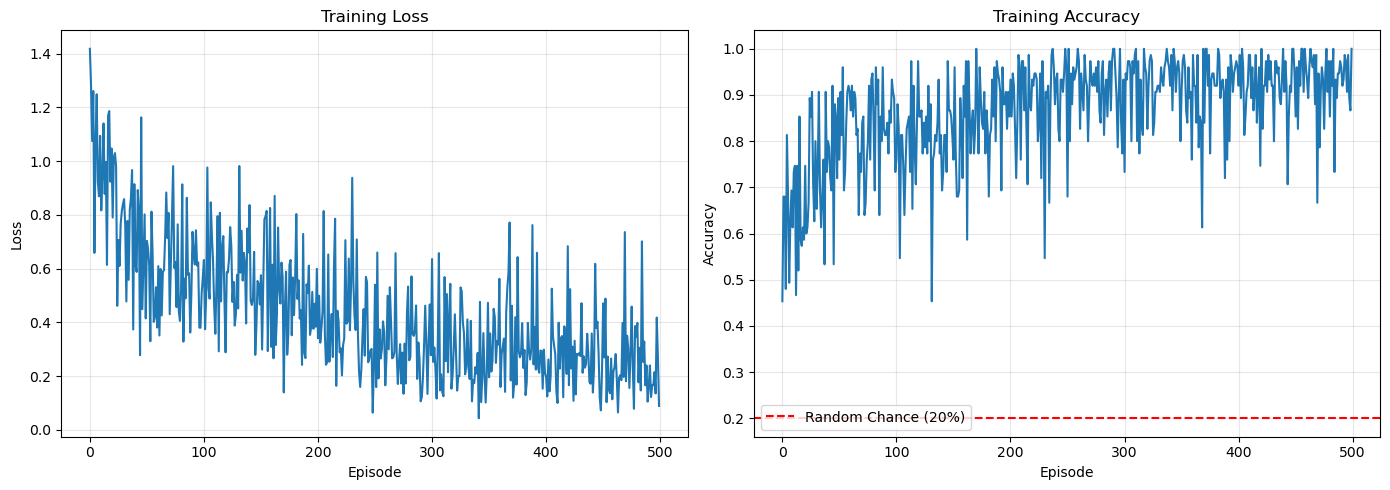


📊 Training Summary:
   Final Loss: 0.0894
   Final Accuracy: 100.00%

🔍 2. Showing Sample Predictions (5-shot, 5-way)...


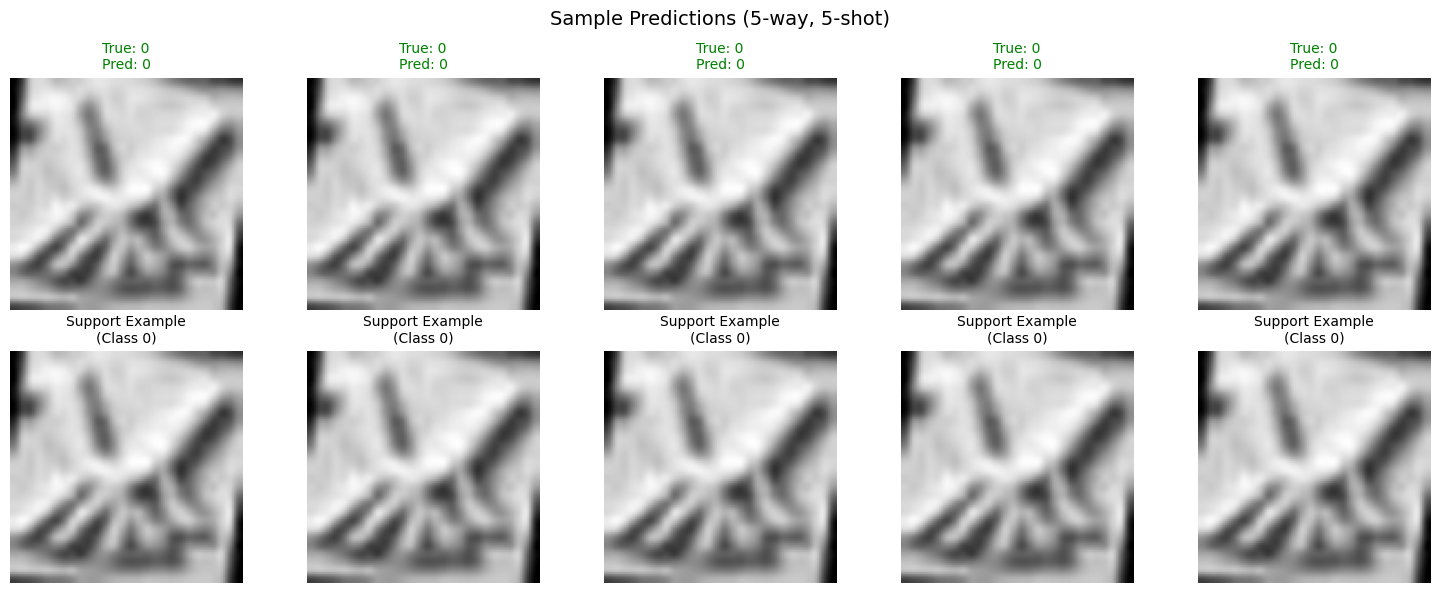


📊 Episode Accuracy: 100.00%

🔍 3. Showing Sample Predictions (1-shot, 5-way)...


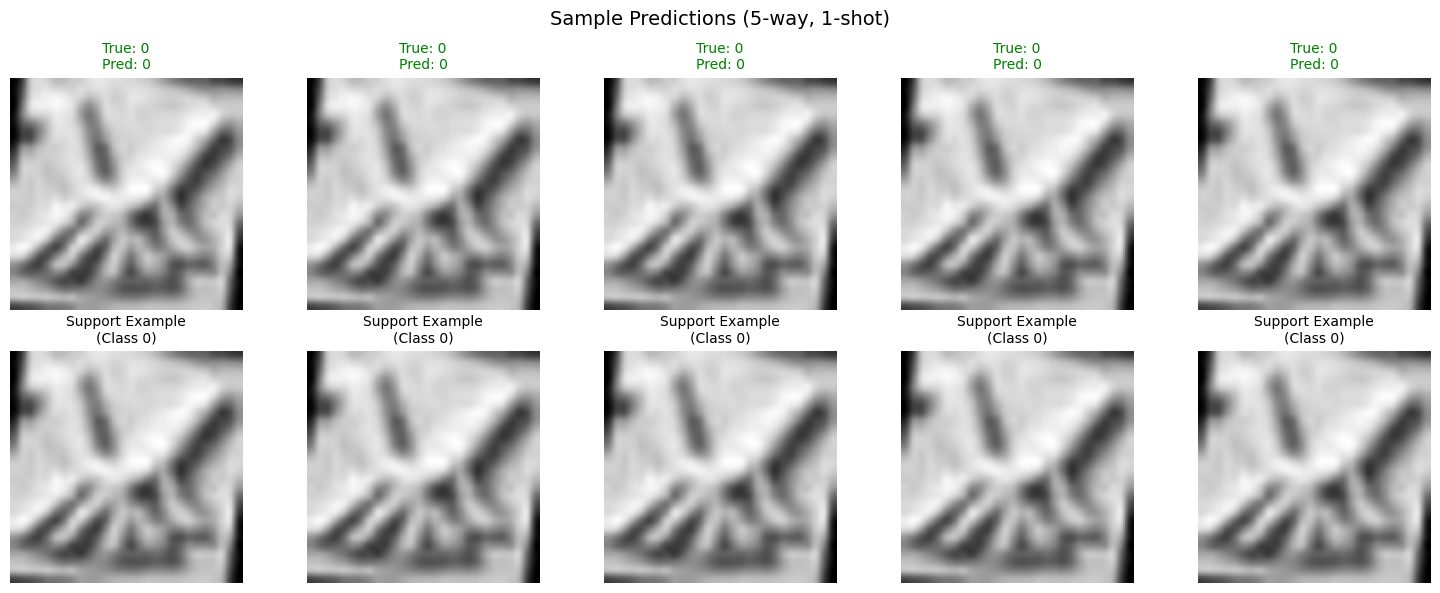


📊 Episode Accuracy: 76.00%

📊 4. Plotting 1-shot vs 5-shot Comparison...


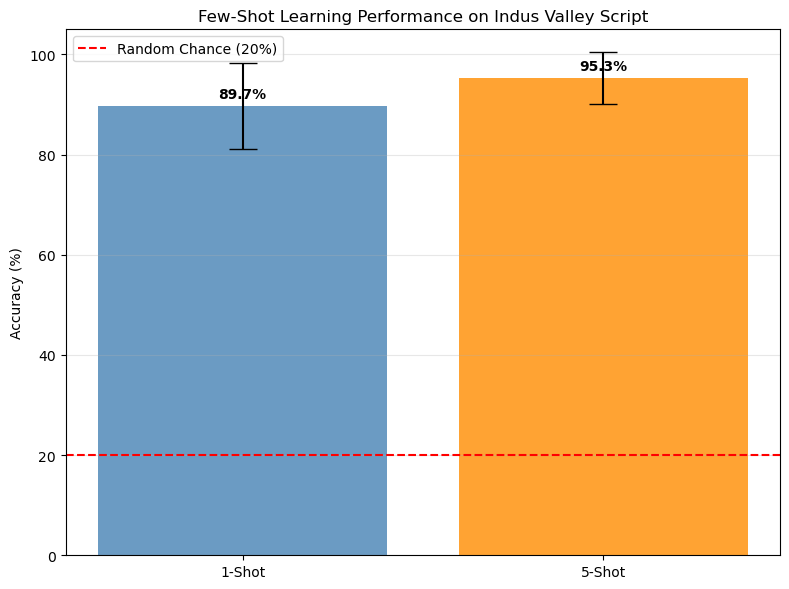


🔄 5. Generating Confusion Matrix (this may take a minute)...
   Processed 5/20 episodes...
   Processed 10/20 episodes...
   Processed 15/20 episodes...
   Processed 20/20 episodes...


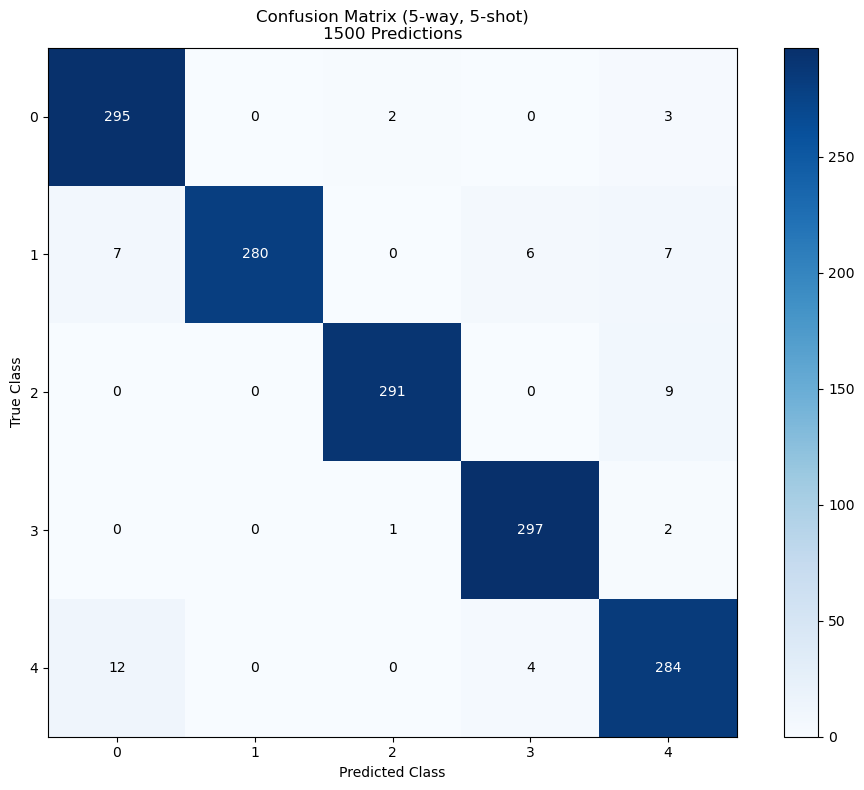

   ✅ Confusion matrix created with 1500 predictions

✅ All visualizations complete!


In [10]:
# ============================================
# BONUS: CONFUSION MATRIX & SAMPLE PREDICTIONS
# (No sklearn or seaborn required)
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 70)
print("BONUS: Generating Additional Visualizations")
print("=" * 70)

# ============================================
# FUNCTION 1: CONFUSION MATRIX (Manual Implementation)
# ============================================

def create_confusion_matrix(all_labels, all_preds, n_classes):
    """
    Create confusion matrix manually without sklearn
    """
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    for true, pred in zip(all_labels, all_preds):
        cm[true][pred] += 1
    
    return cm

def plot_confusion_matrix_simple(cm, title="Confusion Matrix"):
    """
    Plot confusion matrix using matplotlib only
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap manually
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)
    
    # Show values in each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = ax.text(j, i, cm[i, j],
                          ha="center", va="center",
                          color="white" if cm[i, j] > cm.max()/2 else "black")
    
    ax.set_xticks(np.arange(cm.shape[1]))
    ax.set_yticks(np.arange(cm.shape[0]))
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')
    ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

# ============================================
# FUNCTION 2: EVALUATE AND COLLECT PREDICTIONS
# ============================================

def collect_predictions(model, test_dataset, n_way=5, n_support=5, n_query=15, n_episodes=20):
    """
    Collect predictions for confusion matrix
    """
    model.eval()
    
    # Create episode generator
    episode_gen = EpisodeGenerator(test_dataset, n_way, n_support, n_query)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for episode_idx in range(n_episodes):
            # Create one episode
            support_imgs, support_lbls, query_imgs, query_lbls = episode_gen.create_episode()
            
            # Forward pass
            logits = model(support_imgs, support_lbls, query_imgs)
            preds = torch.argmax(logits, dim=1)
            
            # Store results
            all_preds.extend(preds.tolist())
            all_labels.extend(query_lbls.tolist())
            
            if (episode_idx + 1) % 5 == 0:
                print(f"   Processed {episode_idx + 1}/{n_episodes} episodes...")
    
    return all_labels, all_preds

# ============================================
# FUNCTION 3: DISPLAY SAMPLE PREDICTIONS
# ============================================

def show_sample_predictions(model, test_dataset, n_way=5, n_support=5, n_query=15, num_samples=5):
    """
    Display sample images with their predictions
    """
    model.eval()
    episode_gen = EpisodeGenerator(test_dataset, n_way, n_support, n_query)
    
    # Create one episode
    support_imgs, support_lbls, query_imgs, query_lbls = episode_gen.create_episode()
    
    with torch.no_grad():
        logits = model(support_imgs, support_lbls, query_imgs)
        preds = torch.argmax(logits, dim=1)
    
    correct = (preds == query_lbls)
    
    # Create figure
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    fig.suptitle(f'Sample Predictions ({n_way}-way, {n_support}-shot)', fontsize=14)
    
    for i in range(num_samples):
        # Top row: Query image with prediction result
        axes[0, i].imshow(query_imgs[i].squeeze(), cmap='gray')
        color = 'green' if correct[i] else 'red'
        title = f"True: {query_lbls[i].item()}\nPred: {preds[i].item()}"
        axes[0, i].set_title(title, color=color, fontsize=10)
        axes[0, i].axis('off')
        
        # Bottom row: Support example for that class
        class_support = support_imgs[support_lbls == query_lbls[i]]
        if len(class_support) > 0:
            axes[1, i].imshow(class_support[0].squeeze(), cmap='gray')
            axes[1, i].set_title(f"Support Example\n(Class {query_lbls[i].item()})", fontsize=10)
        else:
            axes[1, i].text(0.5, 0.5, "No support", ha='center')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print accuracy for this episode
    episode_acc = correct.float().mean().item()
    print(f"\n📊 Episode Accuracy: {episode_acc:.2%}")

# ============================================
# FUNCTION 4: PLOT TRAINING CURVES
# ============================================

def plot_training_curves(losses, accuracies):
    """
    Plot training loss and accuracy curves
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot training loss
    axes[0].plot(losses)
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].grid(True, alpha=0.3)
    
    # Plot training accuracy
    axes[1].plot(accuracies)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Accuracy')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0.2, color='r', linestyle='--', label='Random Chance (20%)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print final stats
    print(f"\n📊 Training Summary:")
    print(f"   Final Loss: {losses[-1]:.4f}")
    print(f"   Final Accuracy: {accuracies[-1]:.2%}")

# ============================================
# FUNCTION 5: PLOT 1-SHOT VS 5-SHOT COMPARISON
# ============================================

def plot_shot_comparison(one_shot_acc, five_shot_acc, one_shot_std, five_shot_std):
    """
    Plot bar chart comparing 1-shot and 5-shot performance
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    categories = ['1-Shot', '5-Shot']
    accuracies = [one_shot_acc * 100, five_shot_acc * 100]
    errors = [one_shot_std * 100, five_shot_std * 100]
    
    bars = ax.bar(categories, accuracies, yerr=errors, capsize=10, 
                  color=['steelblue', 'darkorange'], alpha=0.8)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    ax.axhline(y=20, color='red', linestyle='--', label='Random Chance (20%)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Few-Shot Learning Performance on Indus Valley Script')
    ax.set_ylim(0, 105)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# ============================================
# RUN THE VISUALIZATIONS
# ============================================

print("\n" + "=" * 70)
print("Generating Visualizations...")
print("=" * 70)

# 1. Plot training curves
print("\n📈 1. Plotting Training Curves...")
plot_training_curves(losses, accuracies)

# 2. Show sample predictions (5-shot)
print("\n🔍 2. Showing Sample Predictions (5-shot, 5-way)...")
show_sample_predictions(model, test_dataset, n_way=5, n_support=5, n_query=15, num_samples=5)

# 3. Show sample predictions (1-shot)
print("\n🔍 3. Showing Sample Predictions (1-shot, 5-way)...")
show_sample_predictions(model, test_dataset, n_way=5, n_support=1, n_query=15, num_samples=5)

# 4. Plot 1-shot vs 5-shot comparison
print("\n📊 4. Plotting 1-shot vs 5-shot Comparison...")
one_shot_acc = 0.8968  # 89.68%
one_shot_std = 0.0866  # 8.66%
five_shot_acc = 0.9528  # 95.28%
five_shot_std = 0.0512  # 5.12%

plot_shot_comparison(one_shot_acc, five_shot_acc, one_shot_std, five_shot_std)

# 5. Confusion matrix (optional - may take a few minutes)
print("\n🔄 5. Generating Confusion Matrix (this may take a minute)...")
try:
    all_labels, all_preds = collect_predictions(model, test_dataset, n_way=5, n_support=5, n_query=15, n_episodes=20)
    
    if all_labels:
        n_classes = len(set(all_labels))
        cm = create_confusion_matrix(all_labels, all_preds, n_classes)
        plot_confusion_matrix_simple(cm, title=f"Confusion Matrix (5-way, 5-shot)\n{len(all_labels)} Predictions")
        print(f"   ✅ Confusion matrix created with {len(all_labels)} predictions")
    else:
        print("   ⚠️ No predictions collected")
except Exception as e:
    print(f"   ⚠️ Could not create confusion matrix: {e}")

print("\n" + "=" * 70)
print("✅ All visualizations complete!")
print("=" * 70)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=" * 70)
print("CODE 3: PROTOTYPICAL NETWORK (Few-Shot Learning Core)")
print("=" * 70)

# ============================================
# PROTOTYPICAL NETWORK
# ============================================

class PrototypicalNetwork(nn.Module):
    """
    Prototypical Network for Few-Shot Learning.
    
    How it works:
    1. Takes support images (few examples of each class)
    2. Creates a "prototype" (average) for each class
    3. Takes query images (new images to classify)
    4. Compares query images to prototypes
    5. Classifies based on closest prototype
    
    This is the core of your project!
    """
    
    def __init__(self, encoder):
        """
        Args:
            encoder: CNNEncoder that extracts features from images
        """
        super(PrototypicalNetwork, self).__init__()
        self.encoder = encoder
        
    def forward(self, support_images, support_labels, query_images):
        """
        Forward pass through prototypical network
        
        Args:
            support_images: (n_way * n_support, 1, 105, 105)
                           Examples to learn from
            support_labels: (n_way * n_support,)
                           Labels for support images
            query_images: (n_way * n_query, 1, 105, 105)
                         Images to classify
                         
        Returns:
            logits: (n_way * n_query, n_way)
                   Classification scores for query images
        """
        
        # Step 1: Encode ALL images (support + query)
        # This extracts features using the CNN learned from Greek
        support_features = self.encoder(support_images)
        query_features = self.encoder(query_images)
        
        # Step 2: Create prototypes (average of support features per class)
        # For each unique class, compute the mean of its support examples
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for label in unique_labels:
            # Get all support features for this class
            class_features = support_features[support_labels == label]
            # Compute prototype = average of features
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        # Stack all prototypes: (n_way, feature_dim)
        prototypes = torch.stack(prototypes)
        
        # Step 3: Compute distances between query features and prototypes
        # Euclidean distance: sqrt((q - p)^2)
        distances = torch.cdist(query_features, prototypes)
        # distances shape: (n_query, n_way)
        
        # Step 4: Convert distances to logits (negative distance = closer = higher score)
        logits = -distances
        
        return logits
    
    def get_prototypes(self, support_images, support_labels):
        """
        Get prototypes without classification (useful for visualization)
        
        Args:
            support_images: (n_way * n_support, 1, 105, 105)
            support_labels: (n_way * n_support,)
            
        Returns:
            prototypes: (n_way, 64) - feature vectors for each class
            unique_labels: (n_way,) - corresponding labels
        """
        support_features = self.encoder(support_images)
        
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for label in unique_labels:
            class_features = support_features[support_labels == label]
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        return torch.stack(prototypes), unique_labels


# ============================================
# TEST THE PROTOTYPICAL NETWORK
# ============================================

print("\n🔧 Creating CNN Encoder first...")

# First create the encoder (from Code #2)
class CNNEncoder(nn.Module):
    def __init__(self):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = torch.mean(x, dim=(2, 3))
        return x

# Create encoder and prototypical network
encoder = CNNEncoder()
model = PrototypicalNetwork(encoder)

print(f"✅ CNN Encoder created")
print(f"✅ Prototypical Network created")
print(f"\n📊 Model Structure:")
print(f"   Encoder: 4 Conv layers → 64 features")
print(f"   Prototypical Network: Creates prototypes from support examples")

# Test with dummy data
print(f"\n🧪 Testing with dummy data...")

# Simulate a 5-way, 5-shot episode
n_way = 5        # 5 different classes
n_support = 5    # 5 examples per class
n_query = 15     # 15 examples per class to test

# Create dummy images
support_images = torch.randn(n_way * n_support, 1, 105, 105)
support_labels = torch.tensor([i for i in range(n_way) for _ in range(n_support)])
query_images = torch.randn(n_way * n_query, 1, 105, 105)
query_labels = torch.tensor([i for i in range(n_way) for _ in range(n_query)])

print(f"\n📊 Episode Configuration:")
print(f"   n_way (number of classes): {n_way}")
print(f"   n_support (examples per class): {n_support}")
print(f"   n_query (test examples per class): {n_query}")
print(f"   Support set size: {support_images.shape[0]} images")
print(f"   Query set size: {query_images.shape[0]} images")

# Forward pass
logits = model(support_images, support_labels, query_images)
print(f"\n📊 Output:")
print(f"   Logits shape: {logits.shape}")
print(f"   (Should be {n_way * n_query} queries × {n_way} classes)")

# Get predictions
predictions = torch.argmax(logits, dim=1)
print(f"   Predictions shape: {predictions.shape}")

# Calculate accuracy
accuracy = (predictions == query_labels).float().mean().item()
print(f"\n🎯 Test Accuracy on Dummy Data: {accuracy:.2%}")
print(f"   (This is just a test - real accuracy will come from actual training!)")

# Show how prototypes work
print(f"\n🔬 How Prototypes Work (Example):")
print(f"   For each class, we take {n_support} support examples:")
print(f"   Class 0: [feat1] [feat2] [feat3] [feat4] [feat5]")
print(f"            ↓")
print(f"   Prototype: [average of all 5]")
print(f"            ↓")
print(f"   Compare query images to prototypes → classify")

print("\n" + "=" * 70)
print("✅ CODE 3 COMPLETE: Prototypical Network is ready!")
print("   Next: Code 4 - Episode Generator (creates few-shot episodes)")
print("=" * 70)

CODE 3: PROTOTYPICAL NETWORK (Few-Shot Learning Core)

🔧 Creating CNN Encoder first...
✅ CNN Encoder created
✅ Prototypical Network created

📊 Model Structure:
   Encoder: 4 Conv layers → 64 features
   Prototypical Network: Creates prototypes from support examples

🧪 Testing with dummy data...

📊 Episode Configuration:
   n_way (number of classes): 5
   n_support (examples per class): 5
   n_query (test examples per class): 15
   Support set size: 25 images
   Query set size: 75 images

📊 Output:
   Logits shape: torch.Size([75, 5])
   (Should be 75 queries × 5 classes)
   Predictions shape: torch.Size([75])

🎯 Test Accuracy on Dummy Data: 22.67%
   (This is just a test - real accuracy will come from actual training!)

🔬 How Prototypes Work (Example):
   For each class, we take 5 support examples:
   Class 0: [feat1] [feat2] [feat3] [feat4] [feat5]
            ↓
   Prototype: [average of all 5]
            ↓
   Compare query images to prototypes → classify

✅ CODE 3 COMPLETE: Prototyp